# Install libraries and import to Venv

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Functions

def heatmap_correlation(df, text):
    plt.figure(figsize=(10, 8)) 
    sns.heatmap(df, annot= True, fmt='.2f', cmap='coolwarm')
    plt.title(f'Correlation Heatmap of {text}')
    plt.show()

def fill_missing_column(df, target, exclude=[]):
    # Get correlations from the heatmap
    correlations = df.corr()[target].drop(labels=[target] + exclude)
    top_features = correlations.abs().sort_values(ascending=False).head(5).index.tolist()

    # Prepare training and prediction sets
    train = df[df[target].notna() & df[top_features].notna().all(axis=1)]
    test = df[df[target].isna() & df[top_features].notna().all(axis=1)]

    # Only proceed if there is something to train on and predict
    if not train.empty and not test.empty:
        model = LinearRegression()
        model.fit(train[top_features], train[target])
        predictions = model.predict(test[top_features])
        df.loc[test.index, target] = predictions

    return df

def replace_categorical(df):
    df['Stage_fear'] = df['Stage_fear'].replace({'Yes': 1, 'No': 0})
    df['Drained_after_socializing'] = df['Drained_after_socializing'].replace({'Yes': 1, 'No': 0})
    if 'Personality' in df.columns:
        df['Personality'] = df['Personality'].replace({'Extrovert': 1, 'Introvert': 0})
    else:
        pass  # Handle case where 'Personality' column does not exist
    
def fill_remaining_with_mode(df, columns):
    for col in columns:
        if df[col].isnull().any():
            df[col].fillna(df[col].mode().iloc[0], inplace=True)
    return df


    

# Data Import

In [4]:
df = pd.read_csv('train.csv')
df.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


# Exploring data for insights

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           17334 non-null  float64
 2   Stage_fear                 16631 non-null  object 
 3   Social_event_attendance    17344 non-null  float64
 4   Going_outside              17058 non-null  float64
 5   Drained_after_socializing  17375 non-null  object 
 6   Friends_circle_size        17470 non-null  float64
 7   Post_frequency             17260 non-null  float64
 8   Personality                18524 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 1.3+ MB


In [6]:
df.describe()

,id,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,18524.000000,17334.000000,17344.000000,17058.000000,17470.000000,17260.000000
mean,9261.500000,3.137764,5.265106,4.044319,7.996737,4.982097
std,5347.562529,3.003786,2.753359,2.062580,4.223484,2.879139
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4630.750000,1.000000,3.000000,3.000000,5.000000,3.000000
50%,9261.500000,2.000000,5.000000,4.000000,8.000000,5.000000
75%,13892.250000,4.000000,8.000000,6.000000,12.000000,7.000000
max,18523.000000,11.000000,10.000000,7.000000,15.000000,10.000000


### Checking Null Values

In [7]:
df.isnull().sum()

id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                1466
Drained_after_socializing    1149
Friends_circle_size          1054
Post_frequency               1264
Personality                     0
dtype: int64

### Checking Unique Values

In [8]:
df.nunique()

id                           18524
Time_spent_Alone                12
Stage_fear                       2
Social_event_attendance         11
Going_outside                    8
Drained_after_socializing        2
Friends_circle_size             16
Post_frequency                  11
Personality                      2
dtype: int64

## Replace stage fear and drained after socializing from Yes/No to 1/0

In [9]:
train_df = df
replace_categorical(train_df)

C:\Users\I748073\AppData\Local\Temp\ipykernel_12012\115467065.py:28: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Stage_fear'] = df['Stage_fear'].replace({'Yes': 1, 'No': 0})
C:\Users\I748073\AppData\Local\Temp\ipykernel_12012\115467065.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Drained_after_socializing'] = df['Drained_after_socializing'].replace({'Yes': 1, 'No': 0})
C:\Users\I748073\AppData\Local\Temp\ipykernel_12012\115467065.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be re

## Selecting only numeric columns

In [10]:
numeric_df = train_df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

In [11]:
numeric_df.describe()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
count,18524.000000,17334.000000,16631.000000,17344.000000,17058.000000,17375.000000,17470.000000,17260.000000,18524.000000
mean,9261.500000,3.137764,0.241838,5.265106,4.044319,0.233784,7.996737,4.982097,0.739527
std,5347.562529,3.003786,0.428209,2.753359,2.062580,0.423249,4.223484,2.879139,0.438905
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4630.750000,1.000000,0.000000,3.000000,3.000000,0.000000,5.000000,3.000000,0.000000
50%,9261.500000,2.000000,0.000000,5.000000,4.000000,0.000000,8.000000,5.000000,1.000000
75%,13892.250000,4.000000,0.000000,8.000000,6.000000,0.000000,12.000000,7.000000,1.000000
max,18523.000000,11.000000,1.000000,10.000000,7.000000,1.000000,15.000000,10.000000,1.000000


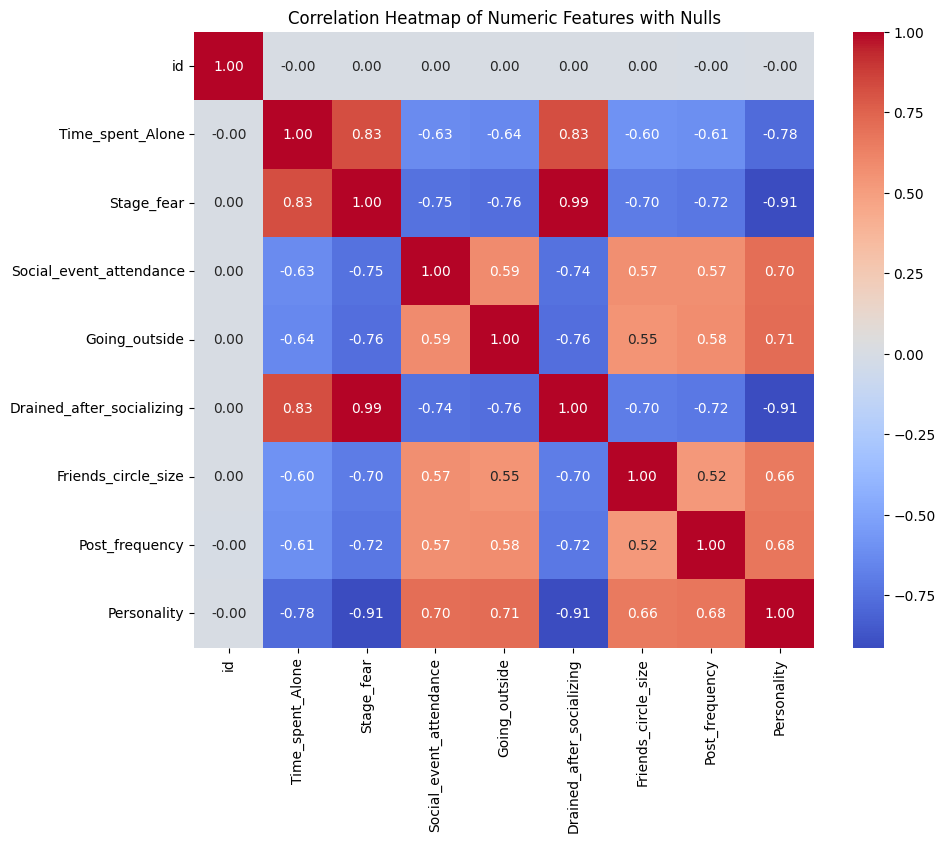

In [12]:
# Calling the function to plot the heatmap
heatmap_correlation(corr_matrix, 'Numeric Features with Nulls')

# Checking difference between nulls

In [13]:
nonulls_df = numeric_df.dropna()
nonulls_df.describe()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
count,10189.000000,10189.000000,10189.000000,10189.000000,10189.000000,10189.000000,10189.000000,10189.000000,10189.000000
mean,9260.691530,2.633134,0.166945,5.681519,4.444793,0.167043,8.503092,5.500834,0.826578
std,5345.623063,2.630621,0.372945,2.597142,1.884790,0.373032,4.073302,2.709847,0.378631
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4653.000000,1.000000,0.000000,4.000000,3.000000,0.000000,5.000000,3.000000,1.000000
50%,9213.000000,2.000000,0.000000,6.000000,5.000000,0.000000,9.000000,6.000000,1.000000
75%,13878.000000,3.000000,0.000000,8.000000,6.000000,0.000000,12.000000,8.000000,1.000000
max,18523.000000,11.000000,1.000000,10.000000,7.000000,1.000000,15.000000,10.000000,1.000000


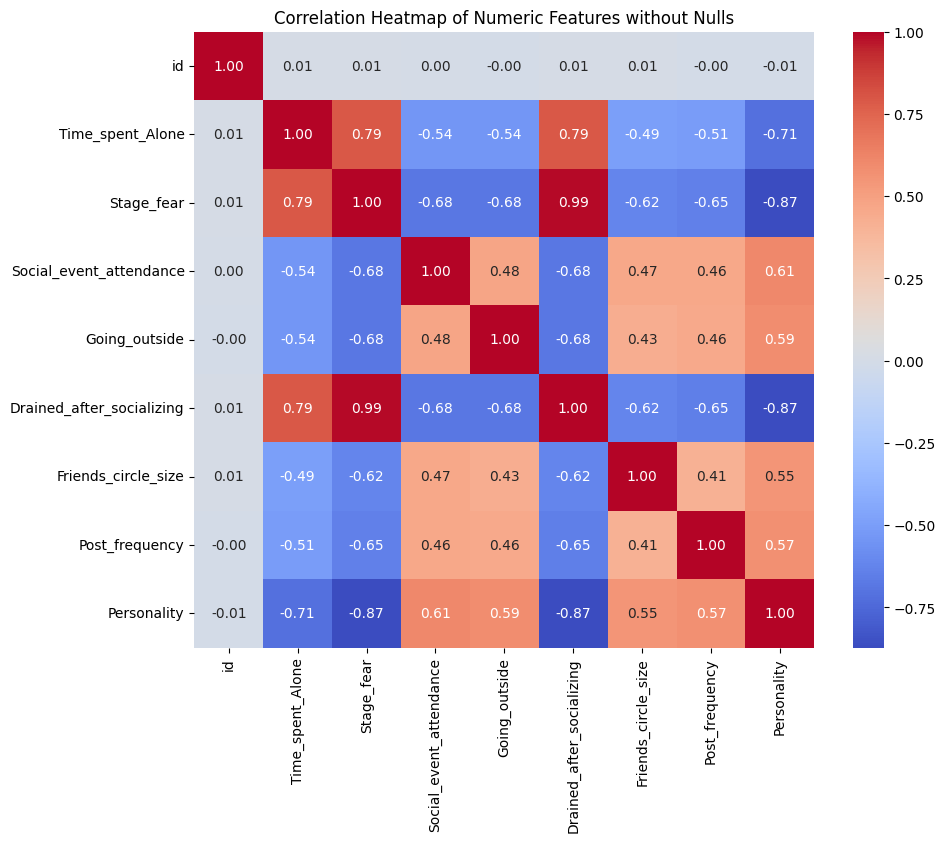

In [14]:
corr_nonulls = nonulls_df.corr()
heatmap_correlation(corr_nonulls, 'Numeric Features without Nulls')

## adding same replacement to test_df to check if correlation is the same

In [15]:
test_df = pd.read_csv('test.csv')
test_df.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
0,18524,3.0,No,7.0,4.0,No,6.0,NaN
1,18525,NaN,Yes,0.0,0.0,Yes,5.0,1.0
2,18526,3.0,No,5.0,6.0,No,15.0,9.0
3,18527,3.0,No,4.0,4.0,No,5.0,6.0
4,18528,9.0,Yes,1.0,2.0,Yes,1.0,1.0


In [16]:
# Replacing categorical values with numerical values in the test dataset
replace_categorical(test_df)

C:\Users\I748073\AppData\Local\Temp\ipykernel_12012\115467065.py:28: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Stage_fear'] = df['Stage_fear'].replace({'Yes': 1, 'No': 0})
C:\Users\I748073\AppData\Local\Temp\ipykernel_12012\115467065.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Drained_after_socializing'] = df['Drained_after_socializing'].replace({'Yes': 1, 'No': 0})


In [17]:
# Selecting numeric columns for correlation analysis
test_numeric_df = test_df.select_dtypes(include=['float64', 'int64'])
test_corr_matrix = test_numeric_df.corr()

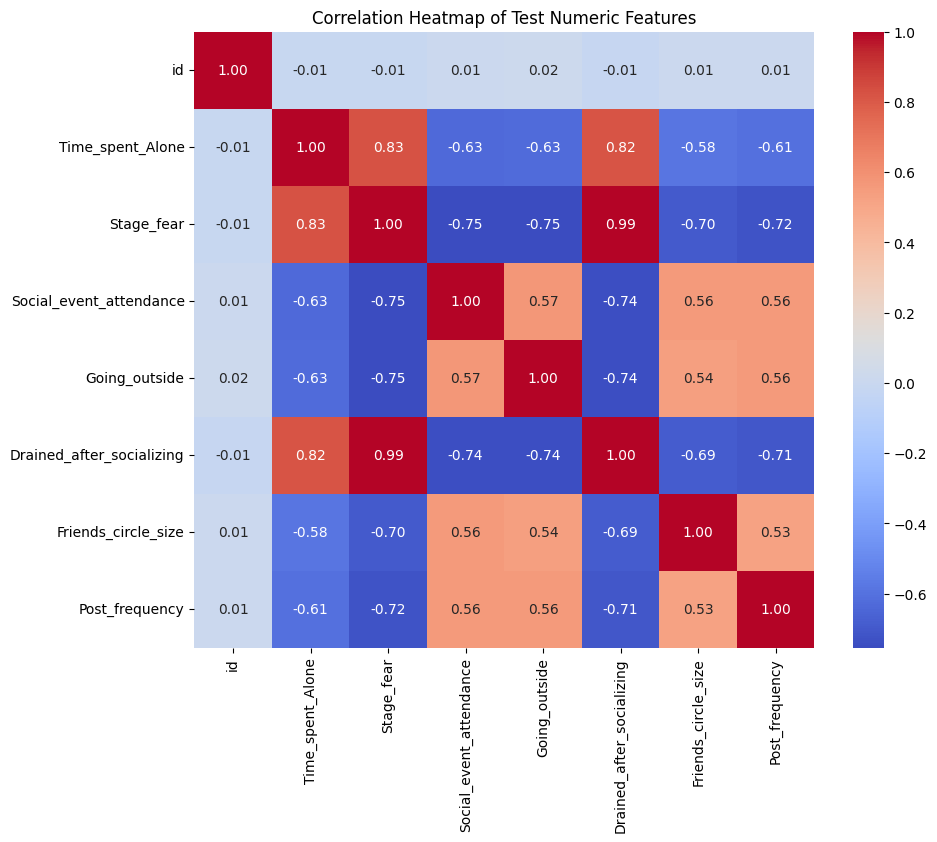

In [18]:
# Calling the function to plot the heatmap for test data
heatmap_correlation(test_corr_matrix, 'Test Numeric Features')

# Using linear regression to replace nulls

In [19]:
# Returning the personality column with labels
df['Personality'] = train_df['Personality'].replace({1: 'Extrovert', 0: 'Introvert'})

In [20]:
# Give an overall view of the data
# sns.pairplot(df, hue = 'Personality')

In [21]:
# Using linear regression to predict the nulls using
from sklearn.linear_model import LinearRegression

columns_to_impute = [
    'Stage_fear', 'Time_spent_Alone', 'Going_outside', 'Drained_after_socializing',
    'Friends_circle_size', 'Post_frequency', 'Social_event_attendance'
]

# Repeat imputation until no nulls remain or no further progress
prev_null_count = -1
while numeric_df.isnull().sum().sum() != 0 and numeric_df.isnull().sum().sum() != prev_null_count:
    prev_null_count = numeric_df.isnull().sum().sum()
    for col in columns_to_impute:
        null_replaced_df = fill_missing_column(numeric_df, col, exclude=['id', 'Personality'])
    numeric_df = null_replaced_df  # update for next iteration

In [22]:
null_replaced_df = fill_remaining_with_mode(numeric_df, columns_to_impute)


C:\Users\I748073\AppData\Local\Temp\ipykernel_12012\115467065.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode().iloc[0], inplace=True)


In [23]:
null_replaced_df.describe()
null_replaced_df.isnull().sum()

id                           0
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64

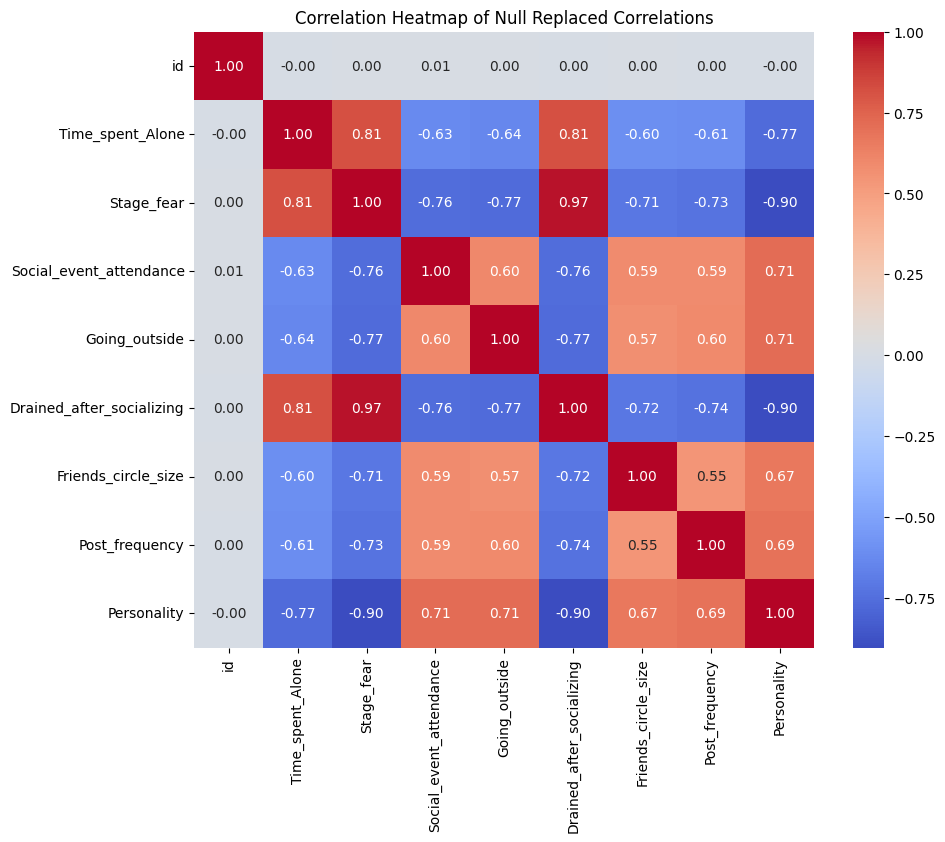

In [24]:
null_replaced_df.corr()
heatmap_correlation(null_replaced_df.corr(), 'Null Replaced Correlations')

In [25]:
# Using linear legression to predict the nulls from the test dataset
from sklearn.linear_model import LinearRegression

columns_to_impute = [
    'Stage_fear', 'Time_spent_Alone', 'Going_outside', 'Drained_after_socializing',
    'Friends_circle_size', 'Post_frequency', 'Social_event_attendance'
]

# Repeat until no nulls remain or no further progress
prev_null_count = -1
while test_numeric_df.isnull().sum().sum() != 0 and test_numeric_df.isnull().sum().sum() != prev_null_count:
    prev_null_count = test_numeric_df.isnull().sum().sum()
    for col in columns_to_impute:
        test_null_replaced_df = fill_missing_column(test_numeric_df, col, exclude=['id'])
    test_numeric_df = test_null_replaced_df  # update for next iteration

In [26]:
test_null_replaced_df = fill_remaining_with_mode(test_numeric_df, columns_to_impute)

C:\Users\I748073\AppData\Local\Temp\ipykernel_12012\115467065.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode().iloc[0], inplace=True)


In [27]:
null_replaced_df.isnull().sum()
null_replaced_df.shape

(18524, 9)

In [28]:
test_null_replaced_df.describe()
test_null_replaced_df.shape

(6175, 8)

In [29]:
final_df = null_replaced_df.copy()
test_final_df = test_null_replaced_df.copy()

In [ ]:
final_df['Personality'] = final_df['Personality'].replace({1: 'Extrovert', 0: 'Introvert'})


KeyError: 'Personality'

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [32]:
# ...existing code...
x_train = final_df.drop(['id', 'Personality'], axis=1)
y_train = final_df['Personality']

# Only split the training data
x_train, x_validate, y_train, y_validate = train_test_split(
    x_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

# Prepare test data separately
x_test = test_final_df.drop(['id'], axis=1)
# ...existing code...

In [33]:
x_test.shape


(6175, 7)

In [34]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [35]:
y_pred = logistic_model.predict(x_validate)

accuracy = accuracy_score(y_validate, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print('classification_report: ')
print(classification_report(y_validate, y_pred))
print('confusion_matrix: ')
print(confusion_matrix(y_validate, y_pred))

Accuracy: 0.971
classification_report: 
              precision    recall  f1-score   support

   Extrovert       0.98      0.98      0.98      3425
   Introvert       0.95      0.94      0.94      1206

    accuracy                           0.97      4631
   macro avg       0.96      0.96      0.96      4631
weighted avg       0.97      0.97      0.97      4631

confusion_matrix: 
[[3366   59]
 [  76 1130]]


In [36]:
len(y_pred)

4631

In [41]:
y_pred = logistic_model.predict(x_test)

submission = pd.DataFrame({
    'id': test_final_df['id'],
    'Personality': y_pred
})

submission['Personality'] = submission['Personality'].replace({1: 'Extrovert', 0: 'Introvert'})

submission.to_csv('submission.csv', index=False)